# **Credit Card Churning Customers Data Analysis**

## Features

* **Customer Age**
* **Gender**
* **Dependent_Count** - How many dependents the customer 
* **Education Level**
* **Marital Status**
* **Income Category** 
* **Months On Book** - How long the customer has been using the credit card service

* **Total Relationship Count** - Number of products the customer has with the bank (e.g., savings, loans, credit card).

* **Months Inactive 12 mon** - Number of months (in the last 12) where the customer had no activity.

* **Contacts Count 12 mon** - How many times the customer contacted the bank in the last 12 months

* **Credit Limit** - Maximum credit available on the card
* **Total Revolving Balance** - Amount the customer is carrying month‑to‑month (not paid off)

* **Avgerag Open To Buy** - Credit_Limit minus Total_Revolving_Bal. Essentially: how much credit they still have available.

* **Total_Amt_Chng_Q4_Q1** - Change in total transaction amount from Q1 to Q4. Measures spending trend (increasing or decreasing).

* **Total_Trans_Amt** - Total amount spent in the last 12 months
* **Total_Trans_Count** - Total number of transactions in the last 12 months
* **Total_Ct_Chng_Q4_Q1** - Change in transaction count from Q1 to Q4



## Target

**Attrition_Flag** - Indication of a customer leaving or staying on the credit card services

## Inputs

* Cleaned_Data and Transformed_Data

## Outputs

* Write here which files, code or artefacts you generate by the end of the notebook.



---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'c:\\Users\\Lailah\\vscode-project\\Credit-Card-Churning-Customers-Analysis-\\jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'c:\\Users\\Lailah\\vscode-project\\Credit-Card-Churning-Customers-Analysis-'

# Section 1

Section 1 content

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [5]:
df = pd.read_csv("Data/Cleaned_Data/Cleaned_Data.csv")
df.head(8)

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000
5,Existing Customer,44,M,2,Graduate,Married,$40K - $60K,Blue,36,3,1,2,4010.0,1247,2763.0,1.376,1088,24,0.846,0.311
6,Existing Customer,51,M,4,Unknown,Married,$120K +,Gold,46,6,1,3,34516.0,2264,32252.0,1.975,1330,31,0.722,0.066
7,Existing Customer,32,M,0,High School,Unknown,$60K - $80K,Silver,27,2,2,2,29081.0,1396,27685.0,2.204,1538,36,0.714,0.048


In [6]:
df_transformed = pd.read_csv("Data/Cleaned_Data/Transformed_Data.csv")
df_transformed.head(8)

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,...,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Gender_M,Marital_Status_Married,Marital_Status_Single,Marital_Status_Unknown,Attrition_Flag_Existing Customer,Education_Level_encoded,Card_Category_encoded
0,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39.0,5,...,42,1.172,0.061,1.0,1.0,0.0,0.0,1.0,2.0,0.0
1,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44.0,6,...,33,1.172,0.105,0.0,0.0,1.0,0.0,1.0,4.0,0.0
2,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36.0,4,...,20,1.172,0.000,1.0,1.0,0.0,0.0,1.0,4.0,0.0
3,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34.0,3,...,20,1.172,0.760,0.0,0.0,0.0,1.0,1.0,2.0,0.0
4,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21.0,5,...,28,1.172,0.000,1.0,1.0,0.0,0.0,1.0,1.0,0.0
5,Existing Customer,44,M,2,Graduate,Married,$40K - $60K,Blue,36.0,3,...,24,0.846,0.311,1.0,1.0,0.0,0.0,1.0,4.0,0.0
6,Existing Customer,51,M,4,Unknown,Married,$120K +,Gold,46.0,6,...,31,0.722,0.066,1.0,1.0,0.0,0.0,1.0,0.0,2.0
7,Existing Customer,32,M,0,High School,Unknown,$60K - $80K,Silver,27.0,2,...,36,0.714,0.048,1.0,0.0,0.0,1.0,1.0,2.0,1.0


In [7]:
df_transformed["Card_Category"].unique()

array(['Blue', 'Gold', 'Silver', 'Platinum'], dtype=object)

In [8]:
df_transformed["Education_Level"].unique()

array(['High School', 'Graduate', 'Uneducated', 'Unknown', 'College',
       'Post-Graduate', 'Doctorate'], dtype=object)

---

# Section 2

Bivariate Analysis

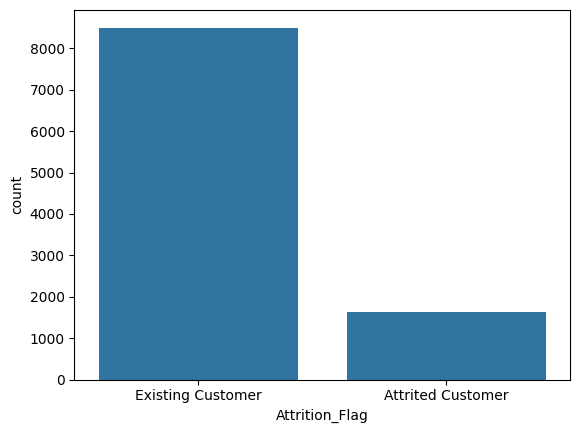

In [9]:
sns.countplot(data=df_transformed, x="Attrition_Flag")
plt.show()

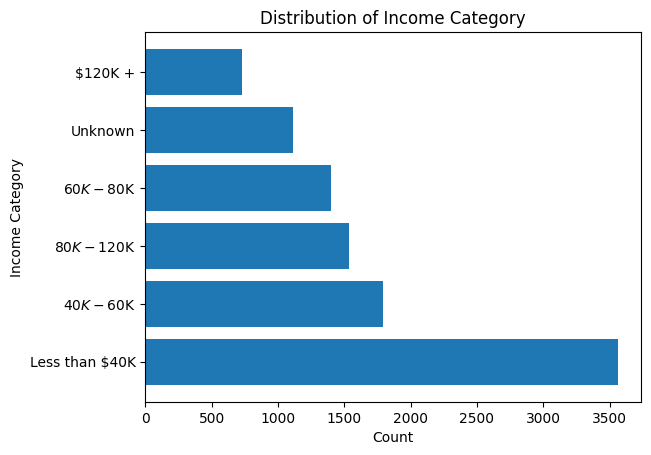

In [10]:
categorial_count=df['Income_Category'].value_counts()
plt.barh(y=categorial_count.index, width=categorial_count.values)
plt.title("Distribution of Income Category")
plt.xlabel("Count")
plt.ylabel("Income Category")
plt.show()
# sns.countplot(data=df_transformed, x="Income_Category")
# plt.tight_layout()
# plt.show()

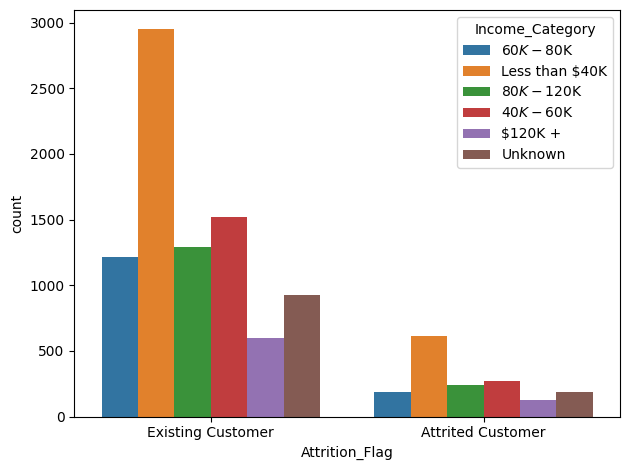

In [11]:
sns.countplot(data=df_transformed,x="Attrition_Flag", hue="Income_Category")
plt.tight_layout()
plt.show()

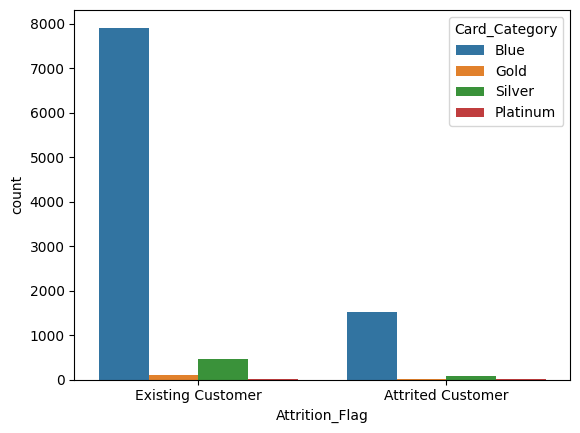

In [12]:
sns.countplot(data=df_transformed, x="Attrition_Flag", hue="Card_Category")
plt.show()

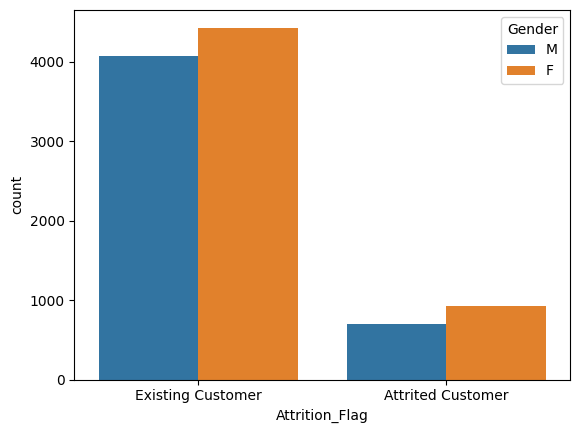

In [13]:
sns.countplot(data=df_transformed, x="Attrition_Flag", hue="Gender")
plt.show()

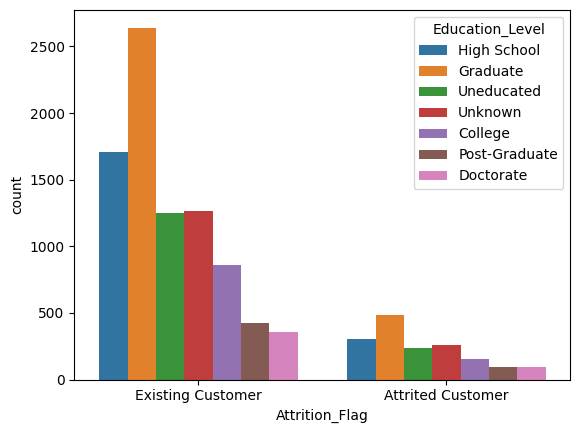

In [14]:
sns.countplot(data=df_transformed, x="Attrition_Flag", hue="Education_Level")
plt.show()

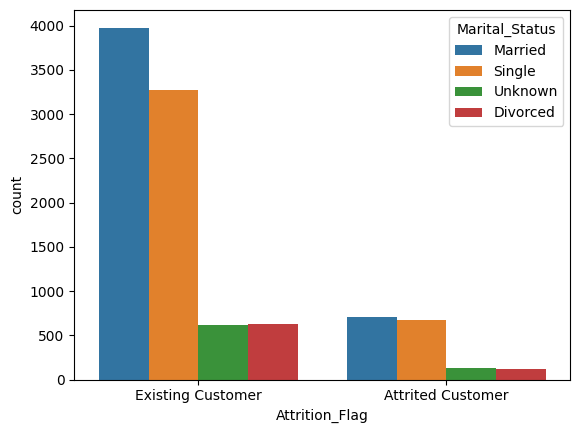

In [15]:
sns.countplot(data=df_transformed, x="Attrition_Flag", hue="Marital_Status")
plt.show()

<Figure size 1000x600 with 0 Axes>

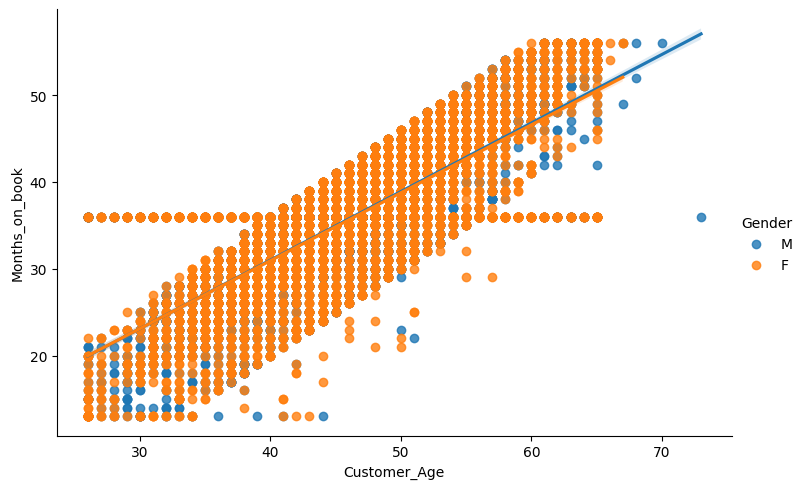

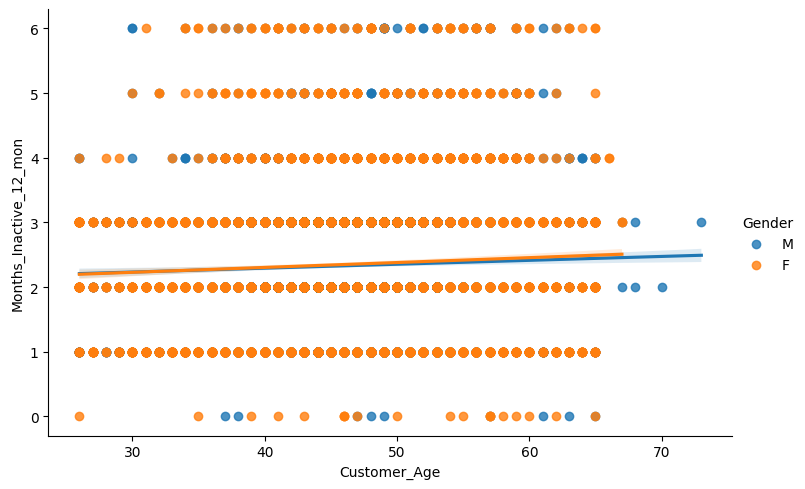

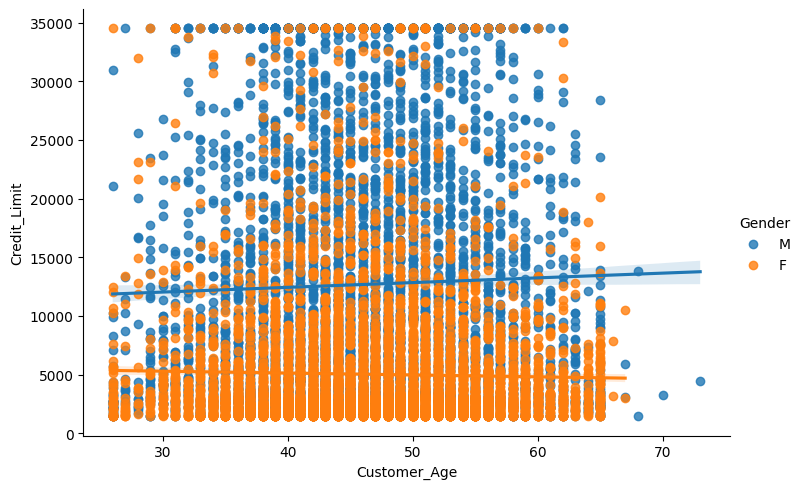

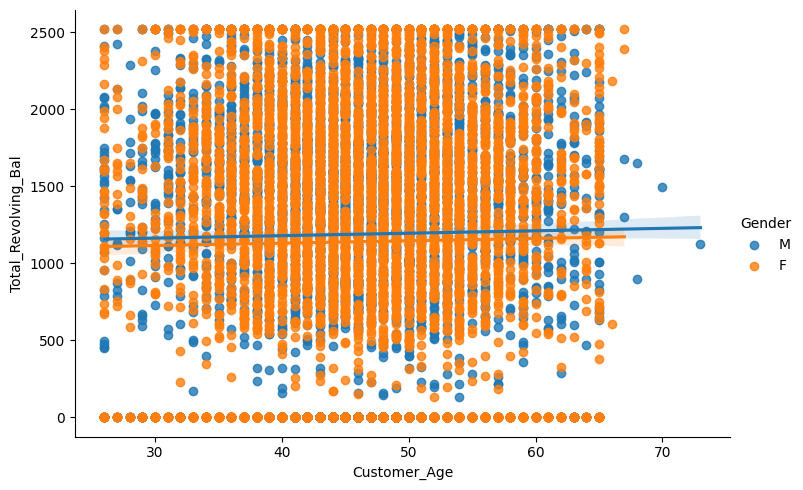

In [16]:
plt.figure(figsize=(10,6))

sns.lmplot(data=df, y='Months_on_book', x='Customer_Age', hue='Gender', height=5, aspect=1.5)
sns.lmplot(data=df, y='Months_Inactive_12_mon', x='Customer_Age', hue='Gender', height=5, aspect=1.5)
sns.lmplot(data=df, y='Credit_Limit', x='Customer_Age', hue='Gender', height=5, aspect=1.5)
sns.lmplot(data=df, y='Total_Revolving_Bal', x='Customer_Age', hue='Gender', height=5, aspect=1.5)
plt.show()

In [21]:
df_corr=df_transformed[['Customer_Age','Dependent_count','Months_on_book','Total_Relationship_Count','Total_Trans_Amt','Total_Trans_Ct','Total_Ct_Chng_Q4_Q1','Avg_Utilization_Ratio','Gender_M','Marital_Status_Married','Education_Level_encoded','Card_Category_encoded','Attrition_Flag_Existing Customer']].corr(method='pearson')
df_corr

,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Gender_M,Marital_Status_Married,Education_Level_encoded,Card_Category_encoded,Attrition_Flag_Existing Customer
Customer_Age,1.000000,-0.122254,0.787856,-0.010931,-0.046446,-0.067097,-0.027717,0.007114,-0.017312,0.047364,-0.002369,-0.018235,-0.018203
Dependent_count,-0.122254,1.000000,-0.106605,-0.039076,0.025046,0.049912,0.012386,-0.037135,0.004563,0.014385,0.000472,0.030469,-0.018991
Months_on_book,0.787856,-0.106605,1.000000,-0.009707,-0.037688,-0.049937,-0.026631,-0.007056,-0.006797,0.032151,0.005617,-0.013007,-0.013538
Total_Relationship_Count,-0.010931,-0.039076,-0.009707,1.000000,-0.347229,-0.241891,0.038028,0.067663,0.003157,0.017001,0.000766,-0.094077,0.150005
Total_Trans_Amt,-0.046446,0.025046,-0.037688,-0.347229,1.000000,0.807192,0.136507,-0.083034,0.024890,-0.063030,-0.007460,0.196003,0.168598
Total_Trans_Ct,-0.067097,0.049912,-0.049937,-0.241891,0.807192,1.000000,0.195717,0.002838,-0.067454,-0.123911,-0.004307,0.134275,0.371403
Total_Ct_Chng_Q4_Q1,-0.027717,0.012386,-0.026631,0.038028,0.136507,0.195717,1.000000,0.084179,-0.020749,0.001193,-0.019913,-0.005207,0.327238
Avg_Utilization_Ratio,0.007114,-0.037135,-0.007056,0.067663,-0.083034,0.002838,0.084179,1.000000,-0.257851,0.049684,-0.001849,-0.198711,0.178410
Gender_M,-0.017312,0.004563,-0.006797,0.003157,0.024890,-0.067454,-0.020749,-0.257851,1.000000,0.011427,-0.005087,0.080093,0.037272
Marital_Status_Married,0.047364,0.014385,0.032151,0.017001,-0.063030,-0.123911,0.001193,0.049684,0.011427,1.000000,0.014051,-0.049254,0.023735


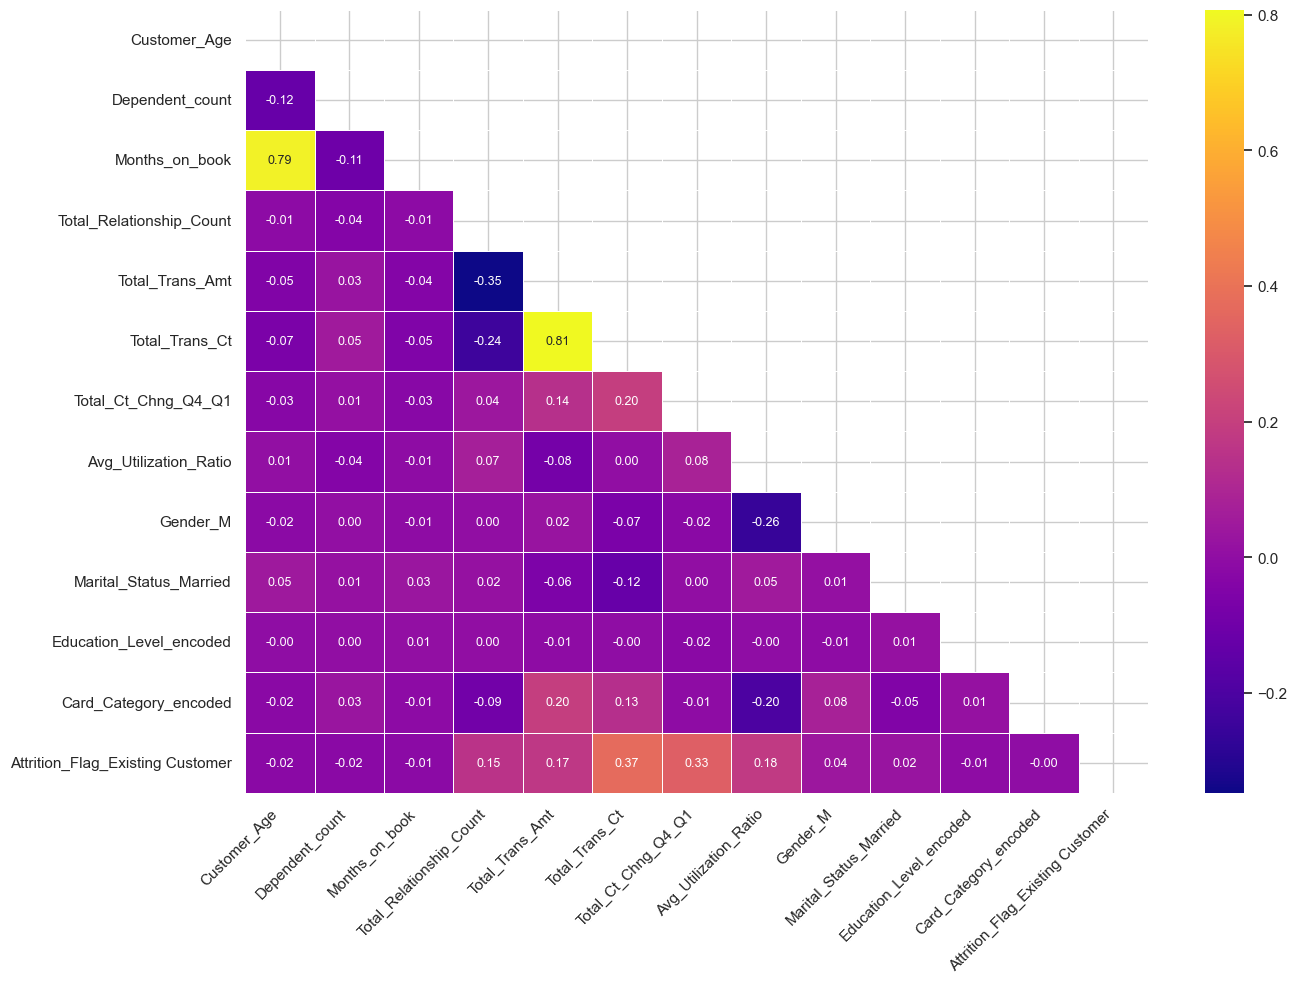

In [43]:
mask=np.zeros_like(df_corr,dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 10))  # bigger canvas spreads annotation text
sns.heatmap(
    df_corr,
    mask=mask,
    annot=True,
    cmap="plasma",
    linewidths=0.5,
    annot_kws={"size": 9},
    fmt=".2f"  # shorter numbers reduce crowding
)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

<Axes: xlabel='Total_Trans_Ct', ylabel='Attrition_Flag'>

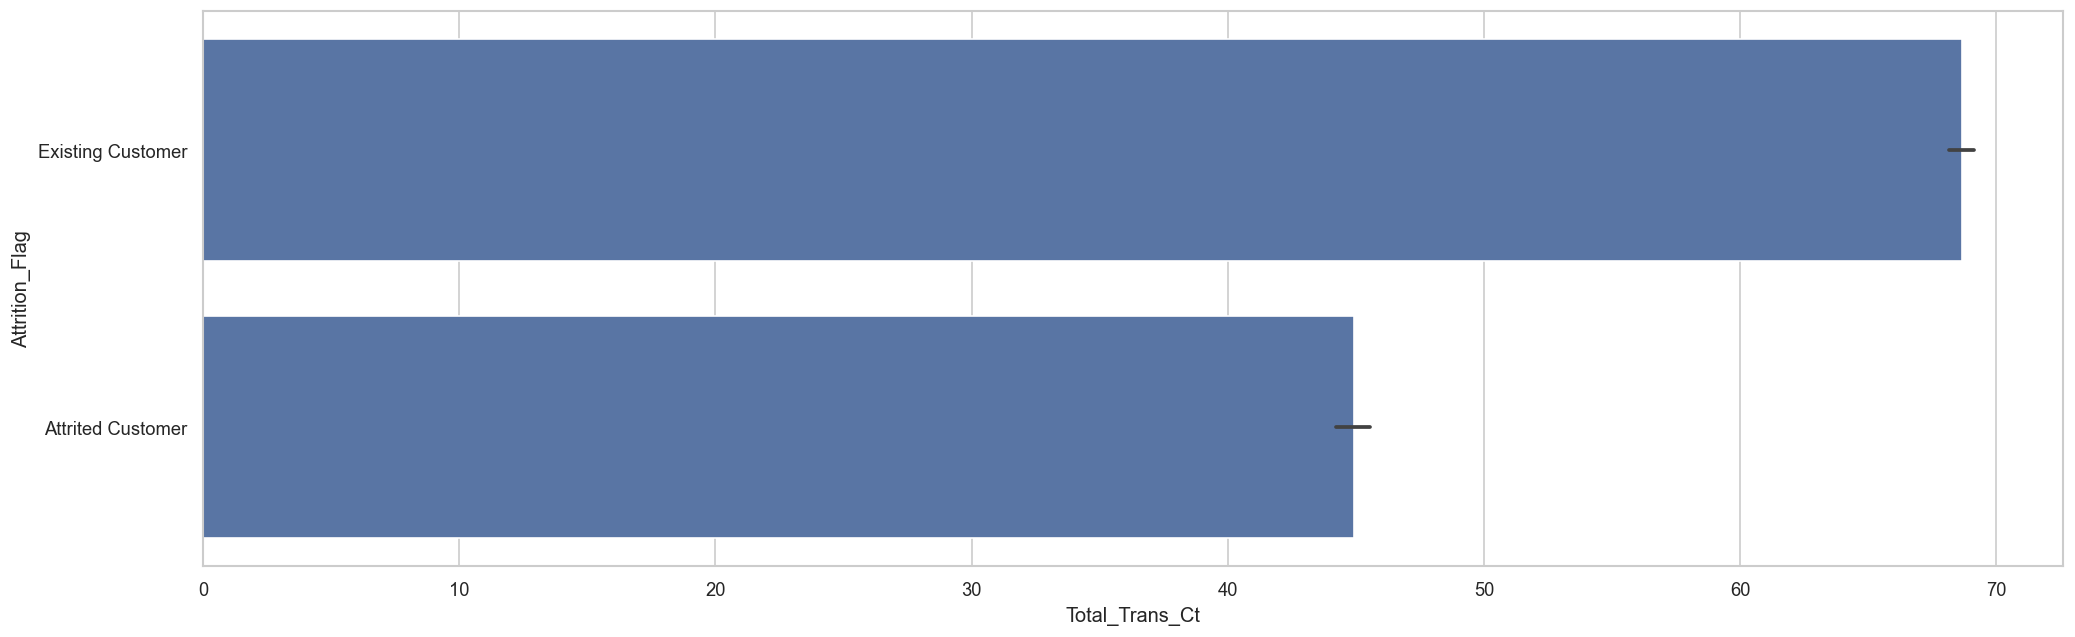

In [47]:
plt.figure(figsize=(20, 6), dpi=120)
sns.barplot(data=df, x='Total_Trans_Ct', y='Attrition_Flag')

<Axes: xlabel='Total_Ct_Chng_Q4_Q1', ylabel='Attrition_Flag'>

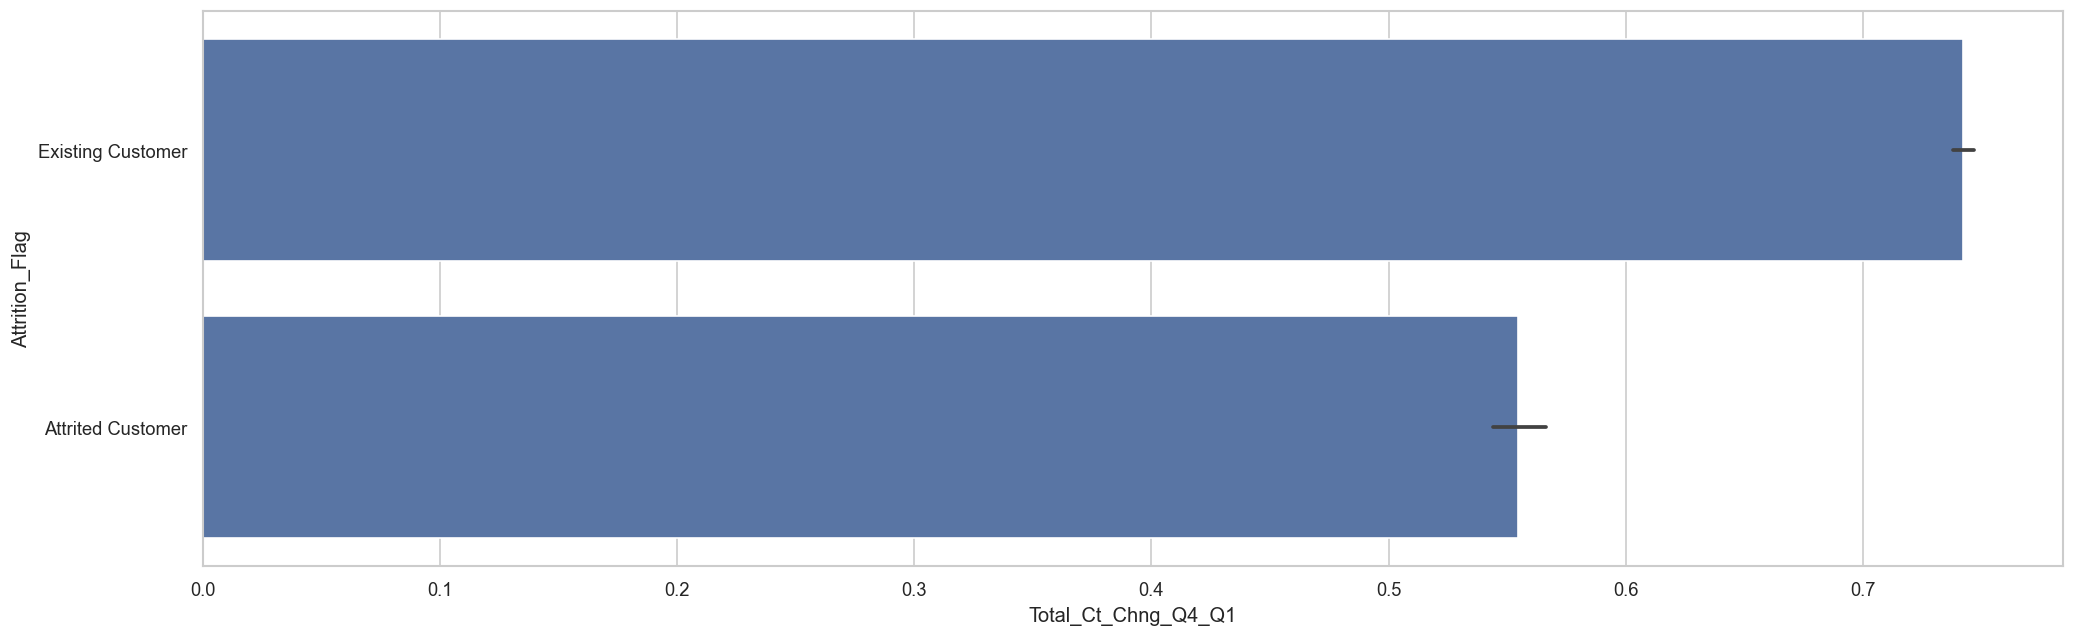

In [48]:
plt.figure(figsize=(20, 6), dpi=120)
sns.barplot(data=df, x='Total_Ct_Chng_Q4_Q1', y='Attrition_Flag')

Text(0.5, 0, 'Customer_Age')

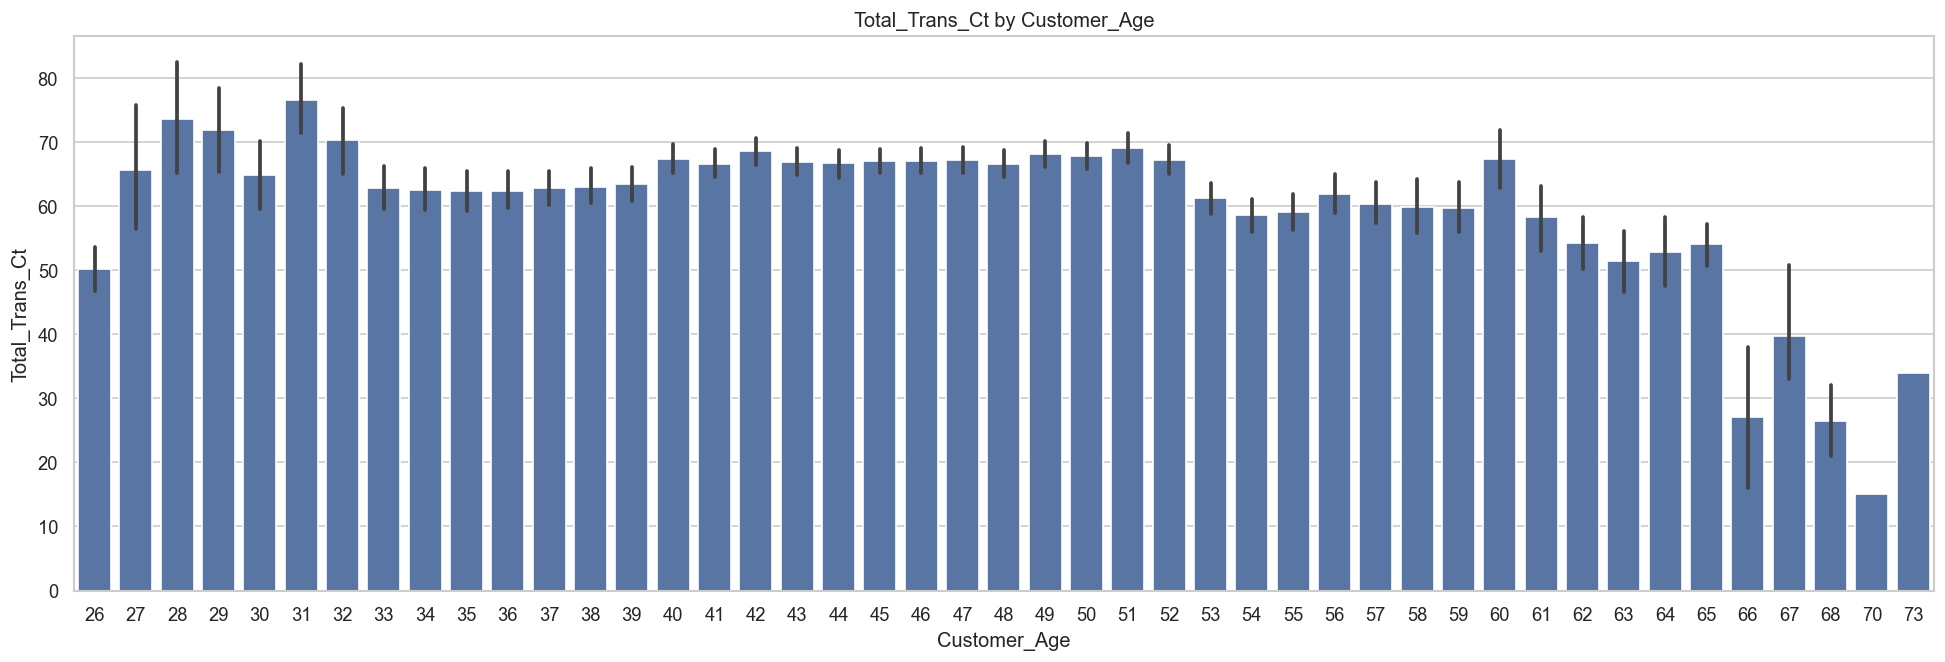

In [46]:
plt.figure(figsize=(20, 6), dpi=120)
sns.barplot(data=df, y='Total_Trans_Ct', x='Customer_Age')
plt.title("Total_Trans_Ct by Customer_Age")
plt.xlabel("Customer_Age")

<Axes: xlabel='Customer_Age', ylabel='Total_Ct_Chng_Q4_Q1'>

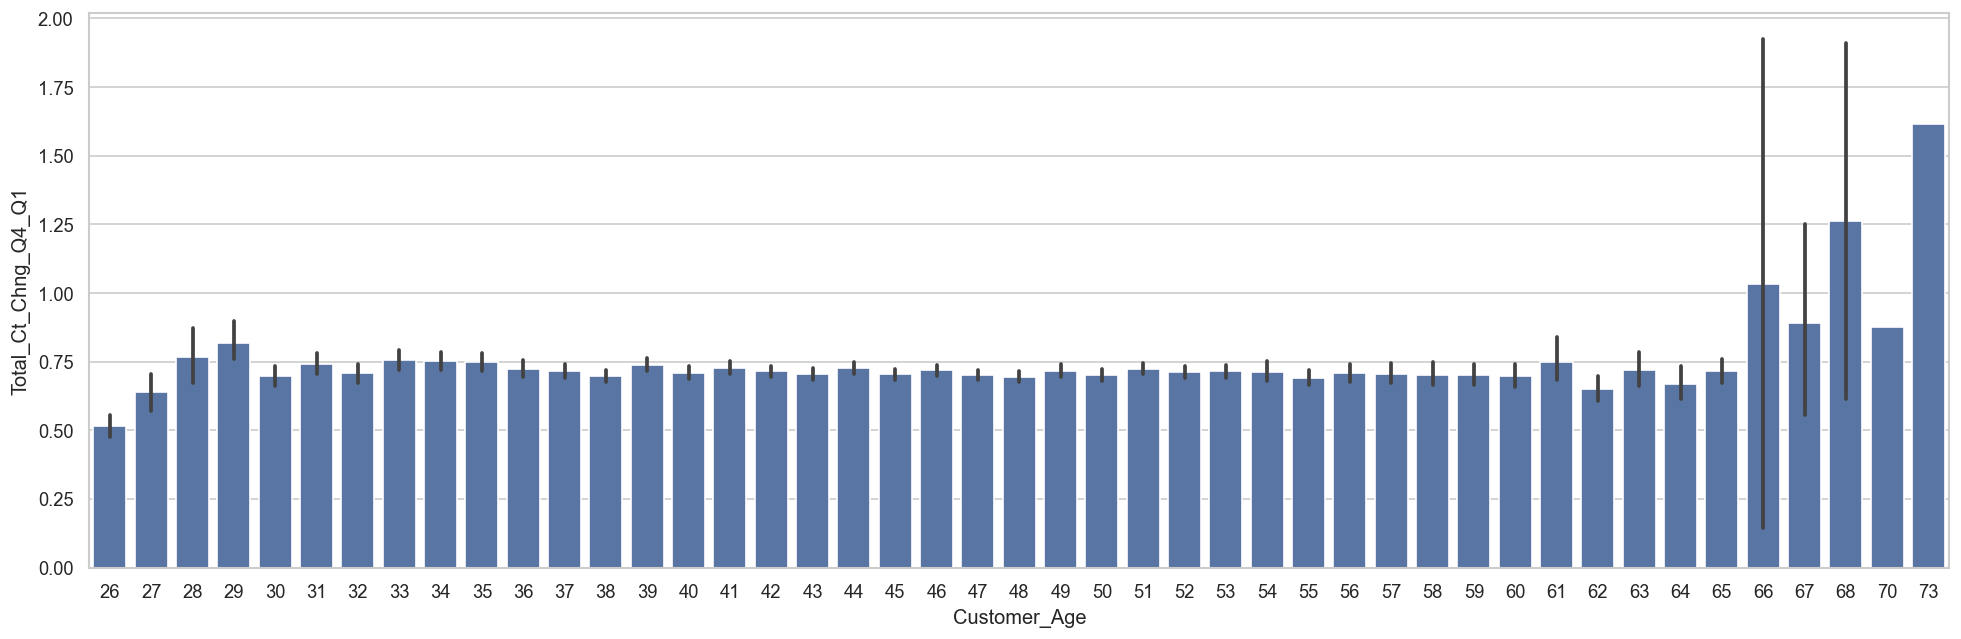

In [45]:
plt.figure(figsize=(20, 6), dpi=120)
sns.barplot(data=df, y='Total_Ct_Chng_Q4_Q1', x='Customer_Age')

---

NOTE

* You may add as many sections as you want, as long as it supports your project workflow.
* All notebook's cells should be run top-down (you can't create a dynamic wherein a given point you need to go back to a previous cell to execute some task, like go back to a previous cell and refresh a variable content)

---

# Push files to Repo

* In cases where you don't need to push files to Repo, you may replace this section with "Conclusions and Next Steps" and state your conclusions and next steps.

In [ ]:
import os
try:
  # create your folder here
  # os.makedirs(name='')
except Exception as e:
  print(e)
